## Введение в автоэнкодеры

### 1. Двумерное кодирование

Заменим одномерное латентое представление на двумерное (два нейрона в скрытом состоянии):

In [5]:
import torch
import torch.nn as nn

class AutoEncoderMNIST(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ELU(inplace=True),
            nn.Linear(128, 64),
            nn.ELU(inplace=True),
            nn.Linear(64, self.hidden_dim)
        )
 
        self.decoder = nn.Sequential(
            nn.Linear(self.hidden_dim, 64),
            nn.ELU(inplace=True),
            nn.Linear(64, 128),
            nn.ELU(inplace=True),
            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )
 
    def forward(self, x):
        h = self.encoder(x)
        x = self.decoder(h)
 
        return x, h

In [6]:
import torchvision
import torchvision.transforms.v2 as tfs_v2
import torch.utils.data as data

model = AutoEncoderMNIST(28 * 28, 28 * 28, 2)
transforms = tfs_v2.Compose([tfs_v2.ToImage(), tfs_v2.ToDtype(dtype=torch.float32, scale=True),
                             tfs_v2.Lambda(lambda _img: _img.ravel())])
 
d_train = torchvision.datasets.MNIST('datasets/mnist', download=True, train=True, transform=transforms)
train_data = data.DataLoader(d_train, batch_size=32, shuffle=True)

In [7]:
import torch.optim as optim
from tqdm import tqdm

optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.MSELoss()
 
epochs = 5
width = len(str(epochs))

model.train()

for _e in range(epochs):
    loss_mean = 0
    lm_count = 0
 
    train_tqdm = tqdm(train_data, leave=True)
    for x_train, y_train in train_tqdm:
        predict, _ = model(x_train)
        loss = loss_func(predict, x_train)
 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        lm_count += 1
        loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean
        train_tqdm.set_description(f'Epoch [{_e+1:>{width}d}/{epochs}], loss_mean={loss_mean:.3f}')

model.eval()

st = model.state_dict()
torch.save(st, 'weights/rnn/model_autoencoder_2_dim_1.tar')

Epoch [5/5], loss_mean=0.039: 100%|██████████| 1875/1875 [00:26<00:00, 70.52it/s]


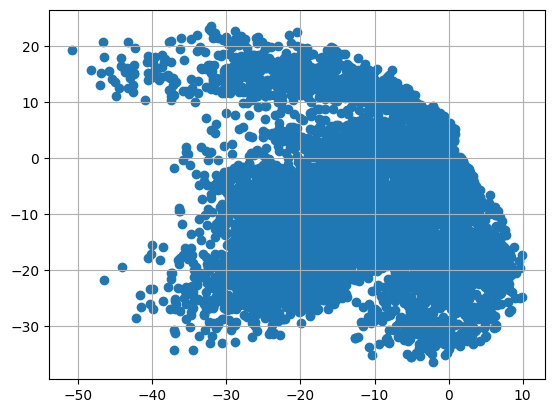

In [8]:
import matplotlib.pyplot as plt

d_test = torchvision.datasets.MNIST('datasets/mnist', download=True, train=False, transform=transforms)
x_data = transforms(d_test.data).view(len(d_test), -1)

h = model.encoder(x_data)
h = h.detach().numpy()
 
plt.scatter(h[:, 0], h[:, 1])
plt.grid()
plt.show()

Если мы будем брать точки в пределах сформированной области, то, скорее всего, на выходе декодера будут получаться осмысленные изображения цифр. Если же брать точку за пределами этой области, то очень вероятно получим какое-то неопределенное изображение. Например, для точки с координатами $h=[-40, -20]$

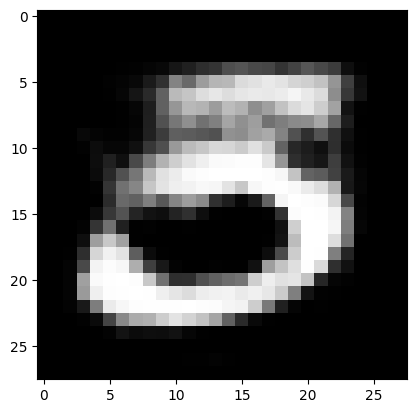

In [9]:
h = torch.tensor([-45, -45], dtype=torch.float32)
predict = model.decoder(h.unsqueeze(0))
predict = predict.detach().squeeze(0).view(28, 28)
dec_img = predict.numpy()
plt.imshow(dec_img, cmap='gray')
plt.show()

Из-за этого автоэнкодеры в чистом виде не практичны для генерации произвольных изображений. То есть, мы не можем брать произвольные точки в области скрытого состояния, чтобы гарантированно получать осмысленные изображения. Чтобы решить эту проблему, пространство состояний скрытого вектора должно быть компактным и представлять единую цельную область без существенных разделений. Первый шаг, который мы можем сделать в направлении формирования компактного распределения векторов скрытого состояния – это добавить слои Batch Normalization после каждого полносвязного слоя в кодере:

In [10]:
class AutoEncoderMNIST(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128, bias=False),
            nn.ELU(inplace=True),
            nn.BatchNorm1d(128), # Добавляем BatchNormalization
            nn.Linear(128, 64, bias=False),
            nn.ELU(inplace=True),
            nn.BatchNorm1d(64),  # Добавляем BatchNormalization
            nn.Linear(64, self.hidden_dim)
        )
 
        self.decoder = nn.Sequential(
            nn.Linear(self.hidden_dim, 64),
            nn.ELU(inplace=True),
            nn.Linear(64, 128),
            nn.ELU(inplace=True),
            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )
 
    def forward(self, x):
        h = self.encoder(x)
        x = self.decoder(h)
 
        return x, h

Epoch [5/5], loss_mean=0.232: 100%|██████████| 1875/1875 [00:24<00:00, 76.85it/s]


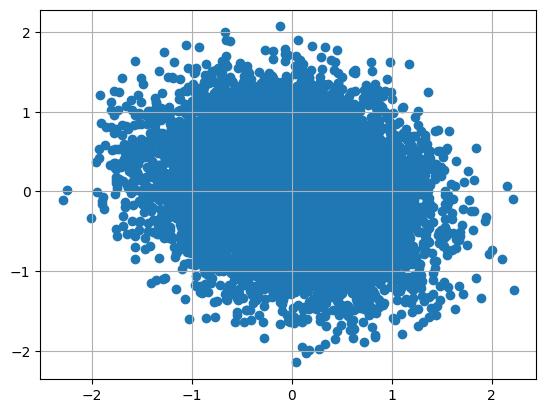

In [11]:
model = AutoEncoderMNIST(28 * 28, 28 * 28, 2)
model.train()

for _e in range(epochs):
    loss_mean = 0
    lm_count = 0
 
    train_tqdm = tqdm(train_data, leave=True)
    for x_train, y_train in train_tqdm:
        predict, _ = model(x_train)
        loss = loss_func(predict, x_train)
 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        lm_count += 1
        loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean
        train_tqdm.set_description(f'Epoch [{_e+1:>{width}d}/{epochs}], loss_mean={loss_mean:.3f}')

model.eval()

st = model.state_dict()
torch.save(st, 'weights/rnn/model_autoencoder_2_dim_2.tar')

h = model.encoder(x_data)
h = h.detach().numpy()
 
plt.scatter(h[:, 0], h[:, 1])
plt.grid()
plt.show()

Лучше, но этот ход не гарантирует требуемое нам распределение.

### 2.Variational Autoencoders (VAE)

В отличие от автоэнкодеров, VAE пытаются сформировать область точек скрытого пространства в соответствии с заданным законом распределения. Часто выбирают нормальное (гауссовское) распределение, так как оно наиболее просто с вычислительной точки зрения, имеет понятную, приемлемую форму и полностью определяется двумя параметрами: математическое ожидание, дисперсия. Они также обучаются алгоритмом Back Propagation.

Например, в случае двумерного вектора скрытого пространства $h=[h_1, h_2]^T$, будем требовать от кодера формирования распределения точек на плоскости в соответствии с двумерной нормальной ПРВ:

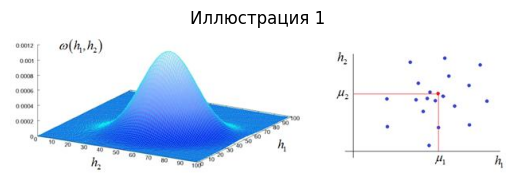

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image1 = mpimg.imread('illustrations/VAE_gauss_distribution.jpg')

plt.imshow(image1)
plt.axis('off')
plt.title('Иллюстрация 1')
plt.show()

Такой подход даст нам уверенную надежду, что любая точка, взятая в пределах полученного распределения, будет давать на выходе декодера осмысленные, понятные изображения. То есть, мы будем понимать как выбирать точки в скрытом пространстве для генерации новых полноценных изображений. Это ключевое отличие вариационного автоэнкодера от обычных автоэнкодеров. Более того, эту же картину можно интерпретировать как преобразование входного пространства большей размерности в компактное скрытое пространство признаков меньшей размерности. Часто это упрощает дальнейший анализ исходных данных.

Сформулируем критерий и построим новую архитектуру автоэнкодера, который будет давать нужное нам распределение векторов скрытого состояния.

### 3. Дивергенция Кульбака-Лейблера

Итак, у нас есть формируемое и желаемое распределения точек скрытого пространства. Обозначим их через
$ \omega_G(h_1, h_2, ...), \omega_N(h_1, h_2, ...) $.

Задачей алгоритма обучения будет не только точно воспроизвести входной сигнал, но и распределить точки скрытого пространства как можно ближе к распределению $ \omega_N(h_1, h_2, ...) $. Значит, нам нужен критерий качества, который бы оценивал степень расхождения между этими двумя распределениями: $ \omega_G(h_1, h_2, ...) $ и $ \omega_N(h_1, h_2, ...) $. В математической теории он называется дивергенция Кульбака-Лейблера. Так как мы предполагаем, что оба распределения будут гауссовскими с независимыми величинами вектора скрытого состояния:

$$ 
h = [h_1, h_2, ..., h_k]^T 
$$,

то расстояние Кульбака-Лейблера для этого случая записывается относительно просто, по следующей формуле:

$$ 
D_{KL} = \frac{1}{2} \left( tr(\Sigma_N^{-1} \Sigma_G) + (\mu_N - \mu_G)^T \Sigma_N^{-1} (\mu_N - \mu_G) - k + \log \left( \frac{\det \Sigma_N}{\det \Sigma_G} \right) \right) 
$$.

Здесь $ \Sigma_G, \Sigma_N $ - ковариационные матрицы вектора СВ. Например, для вектора h при условии независимости его величин, ковариационная матрица будет иметь диагональный вид:

$$
\Sigma_G = M \left( \begin{bmatrix} h_1 \\ h_2 \\ \dots \\ h_k \end{bmatrix} \begin{bmatrix} h_1 & h_2 & \dots & h_k \end{bmatrix} \right) = \begin{bmatrix} \sigma_1^2 & 0 & \dots & 0 \\ 0 & \sigma_2^2 & \dots & 0 \\ \dots & \dots & \dots & \dots \\ 0 & 0 & \dots & \sigma_k^2 \end{bmatrix}
$$

Здесь по главной диагонали стоят дисперсии соответствующих величин. Вторую ковариационную матрицу желаемого распределения можно взять единичной:

$$
\Sigma_N = \begin{bmatrix} 1 & 0 & \dots & 0 \\ 0 & 1 & \dots & 0 \\ \dots & \dots & \dots & \dots \\ 0 & 0 & \dots & 1 \end{bmatrix}
$$

Это будет означать, что многомерная гауссовская ПРВ будет иметь одинаковые дисперсии по всем направлениям (осям), равные 1. И вектор СВ состоит также из независимых величин. Выбор такой ковариационной матрицы очень удобен, т.к. мы сможем ее сократить в критерии качества Кульбака-Лейблера.

Далее, векторы $ \mu_N, \mu_G $ - математическое ожидание для каждой из k величин:
$$ 
\mu_G = [M{h_1}, M{h_2}, ..., M{h_k}]^T 
$$,
$$ 
\mu_N = [0, 0, ..., 0]^T 
$$.

Здесь для желаемого нормального распределения МО выбрали равные нулю. Это значит, центр многомерного распределения $ \omega_N(h_1, h_2, ...) $ будет находиться в начале координат. В итоге вектор $ \mu_N $ также можно будет сократить. В результате, мера Кульбака-Лейблера для нашего частного случая, станет следующей:
$$ 
D_{KL} = \frac{1}{2} \left( tr(\Sigma_G) - \mu_G^T \cdot (-\mu_G) - k + \log \left( \frac{1}{\det \Sigma_G} \right) \right) = 
$$
$$ = \frac{1}{2} \left( tr(\Sigma_G) + \mu_G^T \mu_G - k - \log (\det \Sigma_G) \right) 
$$,

где: $ tr(\Sigma_G) $ - сумма значений элементов главной диагонали матрицы (след матрицы); $ \det \Sigma_G $ - определитель матрицы (для диагональной – произведение значений на главной диагонали).

Итак, мера расхождения двух гауссовых ПРВ у нас есть. И эта мера зависит от векторов МО и дисперсии:
$$ 
\mu_G = [M{h_1}, M{h_2}, ..., M{h_k}]^T 
$$,
$$ 
\sigma_h^2 = [\sigma_1^2, \sigma_2^2, ..., \sigma_k^2]^T 
$$.

Но кодер на выходе выдает не эти величины, а непосредственно вектор скрытого состояния $ h = [h_1, h_2, ..., h_k]^T $. Как же нам вычислять МО и дисперсии текущего распределения и сделать так, чтобы алгоритм обратного распространения ошибки мог использовать эту информацию при обучении VAE? Для этого кодер будет формировать не сам вектор h, а векторы $ \mu, \sigma_h^2 $:

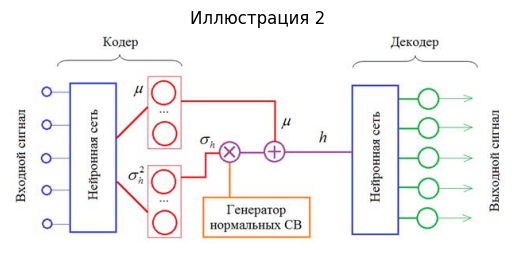

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image2 = mpimg.imread('illustrations/VAE_scheme.jpg')

plt.imshow(image2)
plt.axis('off')
plt.title('Иллюстрация 2')
plt.show()

Здесь генератор НСВ выдает величины с нулевым вектором МО и единичными дисперсиями. Поэтому, после поэлементного умножения на $ \sigma_h $ и сложением с $ \mu $, получим НСВ с этими характеристиками:

$$ 
\tilde{h} = \sigma_h \otimes N + \mu 
$$

То есть, в процессе обучения нейроны кодера будут выдавать векторы МО и дисперсии для каждого входного наблюдения $ x $. Но откуда НС будет «знать», что одна группа нейронов – это МО, а другая – дисперсии? Она такими категориями не «мыслит»! Это происходит по тем же причинам, по которым, например, река течет строго по своему руслу. Законы физики «заставляют» ее течь по ложбинке, а не по возвышенностям. Также и при обучении НС: нейроны приобретают те признаки, которым легче обучиться. Структура вариационного автоэнкодера как раз способствует формированию МО и дисперсии на этих группах нейронов в процессе обучение автоэнкодера.

Теперь, имея эти оценки, можно использовать меру Кульбака-Лейблера для определения соответствия текущего распределения заданному, а также еще один критерий для соответствия входного сигнала выходному. То есть, в процессе обучения VAE будут минимизироваться сразу два этих критерия. Первый будет способствовать формированию правильного распределения векторов h скрытого пространства. А второй – соответствию выходного сигнала входному. Здесь можно так же взять меру минимума среднего квадрата ошибок рассогласования:

$$
MSE = \frac{1}{N} \sum_{i=1}^{N} (x_i - y_i)^2
$$

где $x_i$ - вектор входного сигнала; $y_i$ - вектор выходного сигнала. Результирующий критерий будет равен сумме этих двух величин:

$$
L=MSE+D_{KL}
$$

### 4. Реализация VAE

In [14]:
class AutoEncoderMNIST(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ELU(inplace=True),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ELU(inplace=True),
            nn.BatchNorm1d(64)
        )
 
        self.h_mean = nn.Linear(64, self.hidden_dim)
        self.h_log_var = nn.Linear(64, self.hidden_dim)
 
        self.decoder = nn.Sequential(
            nn.Linear(self.hidden_dim, 64),
            nn.ELU(inplace=True),
            nn.BatchNorm1d(64),
            nn.Linear(64, 128),
            nn.ELU(inplace=True),
            nn.BatchNorm1d(128),
            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )
 
    def forward(self, x):
        enc = self.encoder(x)
 
        h_mean = self.h_mean(enc)
        h_log_var = self.h_log_var(enc)
 
        noise = torch.normal(mean=torch.zeros_like(h_mean), std=torch.ones_like(h_log_var))
        h = noise * torch.exp(h_log_var / 2) + h_mean
        x = self.decoder(h)
 
        return x, h, h_mean, h_log_var

Здесь появились отдельные полносвязные слои для формирования среднего значения (h_mean) и логарифма дисперсии разброса (h_log_var) для векторов скрытого состояния. А в методе forward реализована логика обработки входного тензора x и формирования выходного с дополнительным сохранением векторов скрытого состояния, их средних значений и логарифмов дисперсий. Обратите внимание, что мы работаем с логарифмом дисперсии, а не самой дисперсией. Это связано с удобством дальнейших вычислений. Поэтому в строчке:

```
h = noise * torch.exp(h_log_var / 2) + h_mean
```

Экспонента от h_log_var / 2 соответствует СКО:

$$
\exp(\log \sigma_h^2 / 2) = \exp(\log \sigma_h) = \sigma_h
$$

In [15]:
class VAELoss(nn.Module):
    def forward(self, x, y, h_mean, h_log_var):
        img_loss = torch.sum(torch.square(x - y), dim=-1)
        kl_loss = -0.5 * torch.sum(1 + h_log_var - torch.square(h_mean) - torch.exp(h_log_var), dim=-1)
        return torch.mean(img_loss + kl_loss)

Мы здесь объединяем ошибку квадрата рассогласования между входным и выходным изображениями, а также дивергенцию Кульбака-Лейблера. В методе forward параметры:

- x – тензор входных данных;

- y – тензор выходных данных;

- h_mean – мини-батч средних значений;

- h_log_var - мини-батч логарифмов дисперсий.

Расстояние Кульбака-Лейблера вычисляется с использованием тензоров h_mean и h_log_var. Чтобы лучше понять, как работает эта строчка, положим, что величины h_mean и h_log_var – это векторы длиной k элементов:

$$
\text{h\_mean} = [\mu_1, \mu_2, \dots, \mu_k]^T
$$,

$$
\text{h\_log\_var} = [\log \sigma_1^2, \log \sigma_2^2, \dots, \log \sigma_k^2]^T
$$.

И нам нужно получить формулу:

$$
D_{KL} = -\frac{1}{2} \cdot (k + \log(\det \Sigma_G) - \mu_G^T \mu_G - tr(\Sigma_G))
$$.

Распишем каждое из слагаемых (применительно к нашему случаю независимых СВ):

$$
\log(\det \Sigma_G) = \log(\sigma_1^2 \cdot \sigma_2^2 \cdot \dots \cdot \sigma_k^2) = \sum_{i=1}^{k} \log \sigma_i^2
$$,

$$
\mu_G^T \mu_G = \sum_{i=1}^{k} \mu_i^2
$$,

$$
tr(\Sigma_G) = \sum_{i=1}^{k} \sigma_i^2
$$.

Значит, мы можем взять оценки векторов h_mean и h_log_var и записать все в виде:

```
kl_loss = -0.5 * torch.sum(1 + h_log_var - torch.square(h_mean) - torch.exp(h_log_var), dim=
```

Здесь суммирование будет происходить по длине векторов h_mean и h_log_var, то есть k раз. В итоге получится следующий вектор:

$$
A = \left[ 1 + [\log \sigma_1^2, \dots, \log \sigma_k^2] - [\mu_1^2, \dots, \mu_k^2] - [\sigma_1^2, \dots, \sigma_k^2] \right]
$$.

Суммируем элементы этого вектора, умножаем на -0.5, получаем расстояние Кульбака-Лейблера:

$$
D_{KL} = -0.5 \cdot \left[ k + \sum_{i=1}^{k} (\log \sigma_i^2 - \mu_i^2 - \sigma_i^2) \right]
$$.

In [16]:
model = AutoEncoderMNIST(784, 784, 2)
transforms = tfs_v2.Compose([tfs_v2.ToImage(), tfs_v2.ToDtype(dtype=torch.float32, scale=True),
                             tfs_v2.Lambda(lambda _img: _img.ravel())])
 
d_train = torchvision.datasets.MNIST(r'C:\datasets\mnist', download=True, train=True, transform=transforms)
train_data = data.DataLoader(d_train, batch_size=100, shuffle=True)
 
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = VAELoss()
 
epochs = 5
model.train()
 
for _e in range(epochs):
    loss_mean = 0
    lm_count = 0
 
    train_tqdm = tqdm(train_data, leave=True)
    for x_train, y_train in train_tqdm:
        predict, _, h_mean, h_log_var = model(x_train)
        loss = loss_func(predict, x_train, h_mean, h_log_var)
 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        lm_count += 1
        loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean
        train_tqdm.set_description(f"Epoch [{_e+1}/{epochs}], loss_mean={loss_mean:.3f}")
 
st = model.state_dict()
torch.save(st, 'weights/rnn/model_autoencoder_2_dim_3.tar')

Epoch [5/5], loss_mean=40.308: 100%|██████████| 600/600 [00:22<00:00, 26.33it/s]


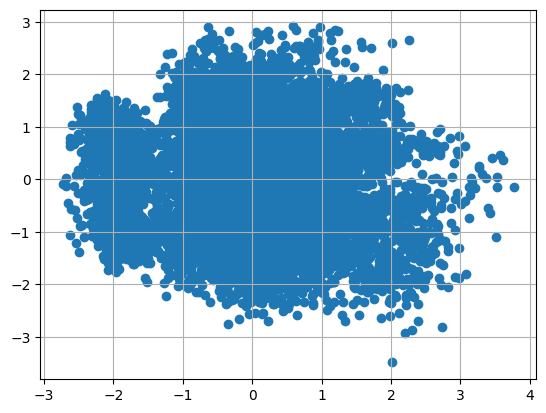

In [17]:
model.eval()
 
_, h, _, _ = model(x_data)
h = h.detach().numpy()
 
plt.scatter(h[:, 0], h[:, 1])
plt.grid()
plt.show()

Распределение получилось близкое к требуемому. Теперь, мы можем брать любые точки из этого пространства и должны при этом получать осмысленные изображения. Проверим это. В квадрате (-3;3) возьмем равномерно точки и подадим на вход декодера:

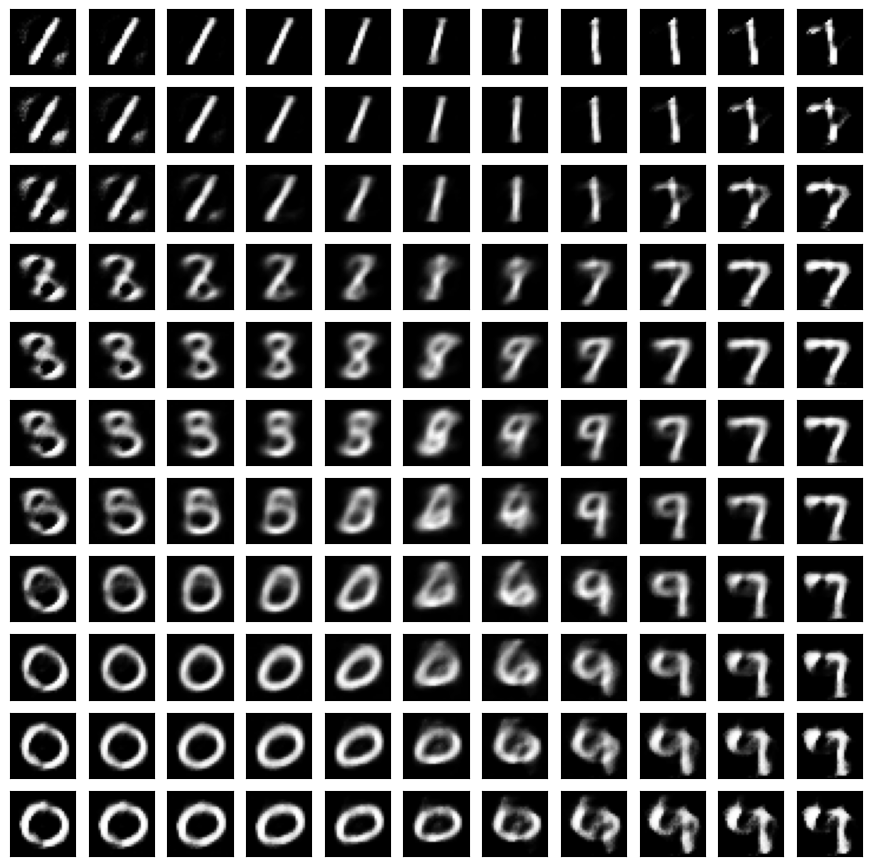

In [18]:
n = 5
total = 2*n+1
 
plt.figure(figsize=(total, total))
 
num = 1
for i in range(-n, n+1):
    for j in range(-n, n+1):
        ax = plt.subplot(total, total, num)
        num += 1
        h = torch.tensor([3*i/n, 3*j/n], dtype=torch.float32)
        predict = model.decoder(h.unsqueeze(0))
        predict = predict.detach().squeeze(0).view(28, 28)
        dec_img = predict.numpy()
 
        plt.imshow(dec_img, cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
 
plt.show()

В верхнем правом углу образы получились не очень понятные. Это вполне возможно, так как в точке (3; 3) имеем самый край области и там могут быть неопределенные изображения. Также видим, что некоторые цифры отсутствуют, а некоторые изображения представляют собой переход из одной цифры в другую. 

Это естественный результат, так как мы выбрали лишь некоторые из точек пространства, которые расположены в областях строго определенных цифр. При этом сами цифры группируются в пространстве векторов скрытого состояния. Мы можем выделять группы из семерок, единиц, нулей. Чтобы знать, какая область отвечает за генерацию изображения той или иной цифры, достаточно вычислить ее среднее значение и дисперсию с помощью модели кодера:

C:\Users\mrkee\AppData\Local\Temp\ipykernel_14208\3133859682.py:22: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  h = torch.tensor([3 * h_std[0] * i/n + h_mean[0], 3 * h_std[1] * j/n + h_mean[1]], dtype=torch.float32)


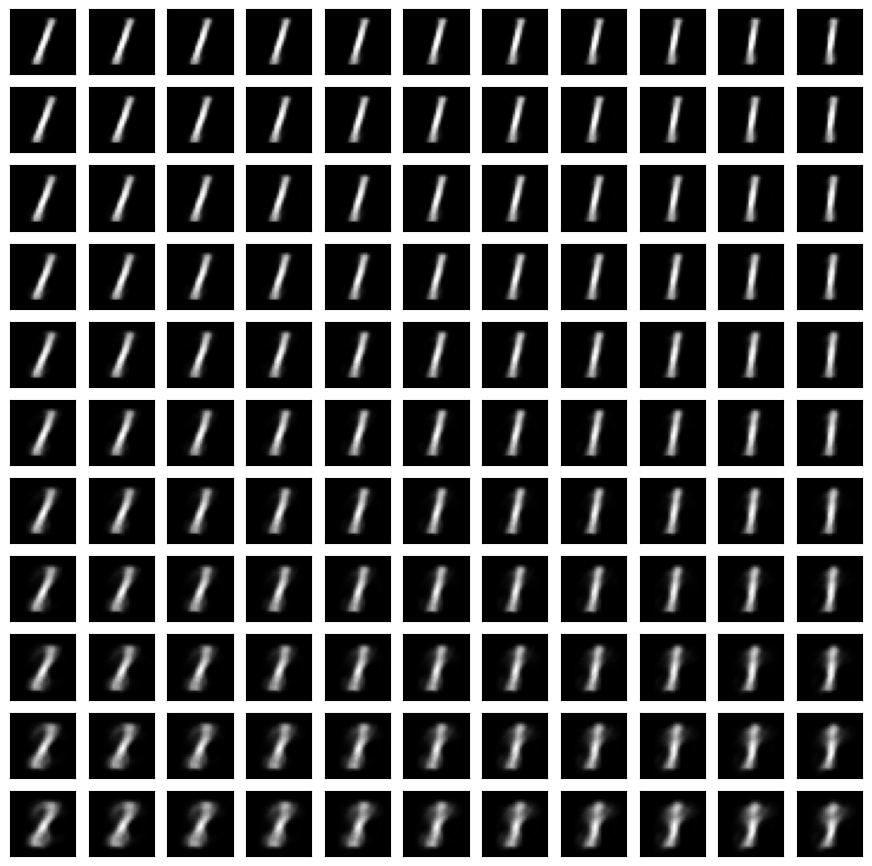

In [19]:
x_data = d_train.data[d_train.targets == 1]
batch_size = x_data.size(0)

x_data = transforms(x_data).view(batch_size, -1)
enc = model.encoder(x_data)

h_mean, h_log_var = model.h_mean(enc), model.h_log_var(enc)
h_mean = torch.mean(h_mean, dim=0)

h_std = torch.mean(torch.exp(h_log_var / 2), dim=0)
 
n = 5
total = 2*n+1
 
plt.figure(figsize=(total, total))
 
num = 1
for i in range(-n, n+1):
    for j in range(-n, n+1):
        ax = plt.subplot(total, total, num)
        num += 1
        h = torch.tensor([3 * h_std[0] * i/n + h_mean[0], 3 * h_std[1] * j/n + h_mean[1]], dtype=torch.float32)
        predict = model.decoder(h.unsqueeze(0))
        predict = predict.detach().squeeze(0).view(28, 28)
        dec_img = predict.numpy()
 
        plt.imshow(dec_img, cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
 
plt.show()